# **Machine Learning with XGboost in Python**

Welcome to this code-along, where we will use XGBoost to predict booking cancellations with gradient boosting, a powerful machine learning technique! Through this, you'll learn how to create, evaluate, and tune XGBoost models efficiently. There will be time to answer any questions, so please add them!

## **The Dataset**

The session's dataset is a CSV file named `hotel_bookings_clean.csv`, which contains data on hotel bookings.

### **Acknowledgements**
The dataset was downloaded on [Kaggle](https://www.kaggle.com/jessemostipak/hotel-booking-demand/). The data is originally from an article called [Hotel booking demand datasets](https://www.sciencedirect.com/science/article/pii/S2352340918315191) by Nuno Antonio, Ana de Almeida, and Luis Nunes. It was then cleaned by Thomas Mock and Antoine Bichat for [#TidyTuesday during the week of February 11th, 2020](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md). For the purposes of this code-along, it was further pre-processed to have cleaner ready-to-use features (e.g., dropping irrelevant columns, one-hot-encoding). The dataset has the following [license](https://creativecommons.org/licenses/by/4.0/).

### **Data Dictionary**

It contains the **53 columns**:

_For binary variables: `1` = true and `0` = false._

#### **Target**
- `is_canceled`: Binary variable indicating whether a booking was canceled

#### **Features**
- `lead time`: Number of days between booking date and arrival date
- `arrival_date_week_number`, `arrival_date_day_of_month`, `arrival_date_month`: Week number, day date, and month number of arrival date
- `stays_in_weekend_nights`, `stays_in_week_nights`: Number of weekend nights (Saturday and Sunday) and weeknights (Monday to Friday) the customer booked
- `adults`,`children`,`babies`: Number of adults, children, babies booked for the stay
- `is_repeated_guest`: Binary variable indicating whether the customer was a repeat guest
- `previous_cancellations`: Number of prior bookings that were canceled by the customer
- `previous_bookings_not_canceled`: Number of prior bookings that were not canceled by the customer
- `required_car_parking_spaces`: Number of parking spaces requested by the customer
- `total_of_special_requests`: Number of special requests made by the customer
- `avg_daily_rate`: Average daily rate, as defined by dividing the sum of all lodging transactions by the total number of staying nights
- `booked_by_company`: Binary variable indicating whether a company booked the booking
- `booked_by_agent`: Binary variable indicating whether an agent booked the booking
- `hotel_City`: Binary variable indicating whether the booked hotel is a "City Hotel"
- `hotel_Resort`: Binary variable indicating whether the booked hotel is a "Resort Hotel"
- `meal_BB`: Binary variable indicating whether a bed & breakfast meal was booked
- `meal_HB`: Binary variable indicating whether a half board meal was booked
- `meal_FB`: Binary variable indicating whether a full board meal was booked
- `meal_No_meal`: Binary variable indicating whether there was no meal package booked
- `market_segment_Aviation`, `market_segment_Complementary`, `market_segment_Corporate`, `market_segment_Direct`, `market_segment_Groups`, `market_segment_Offline_TA_TO`, `market_segment_Online_TA`, `market_segment_Undefined`: Indicates market segment designation with a value of `1`. "TA"= travel agent, "TO"= tour operators
- `distribution_channel_Corporate`, `distribution_channel_Direct`, `distribution_channel_GDS`, `distribution_channel_TA_TO`, `distribution_channel_Undefined`: Indicates booking distribution channel with a value of `1`. "TA"= travel agent, "TO"= tour operators, "GDS" = Global Distribution System
- `reserved_room_type_A`,`reserved_room_type_B`, `reserved_room_type_C`,`reserved_room_type_D`, `reserved_room_type_E`, `reserved_room_type_F`, `reserved_room_type_G`, `reserved_room_type_H`, `reserved_room_type_L`: Indicates code of room type reserved with a value of `1`. Code is presented instead of designation for anonymity reasons
- `deposit_type_No_Deposit`: Binary variable indicating whether a deposit was made
- `deposit_type_Non_Refund`: Binary variable indicating whether a deposit was made in the value of the total stay cost
- `deposit_type_Refundable`: Binary variable indicating whether a deposit was made with a value under the total stay cost
- `customer_type_Contract`: Binary variable indicating whether the booking has an allotment or other type of contract associated to it
- `customer_type_Group`: Binary variable indicating whether the booking is associated to a group
- `customer_type_Transient`: Binary variable indicating whether the booking is not part of a group or contract, and is not associated to other transient booking
- `customer_type_Transient-Party`: Binary variable indicating whether the booking is transient, but is associated to at least another transient booking

---



In [ ]:
!sudo apt-get install graphviz && sudo apt-get upgrade

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Calculating upgrade... Done
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


#### **1. Getting to know our data**

Let's get to know our columns and split our data into features and labels!

In [ ]:
# Import libraries
import pandas as pd
import xgboost as xgb # XGBoost typically uses the alias "xgb"
import numpy as np

In [ ]:
# Read in the dataset
bookings = pd.read_csv('hotel_bookings_clean.csv')

### **Splitting data**
Let's split our label and features so we can get to building models! The first column is our target label `is_canceled`. The rest are features.

In [ ]:
# Define X and y
X, y = bookings.iloc[:,1:], bookings.iloc[:,0]

from sklearn.model_selection import train_test_split

# Train and test split using sklearn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.33, random_state=123)

## **4. Hyperparameter tuning with Random Search**

Grid search and random search are the most popular methods for hyperparameter tuning. However, grid search can get computationally expensive if you are searching over a large hyperparameter space and dealing with multiple hyperparameters. This is why we'll use random search because it doesn't try all the hyperparameter values. In random search, a fixed number of hyperparameter settings is sampled from specified probability distributions.

XGBoost doesn't have a built-in gridsearch function, so we need to use `scikit-learn`'s [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html). This means we'll have to use `XGBClassifier()` because it's `scikit-learn` compatible.


<p align="center">
<img src="https://github.com/datacamp/Machine-Learning-With-XGboost-live-training/blob/master/assets/randomized_search_1.gif?raw=true" width = "50%">
</p>


<br>

The `RandomizedSearchCV()` function takes in the following arguments:

- `estimator`: The estimator being fit, here it's XGBoost.
- `param_distributions`: Unlike `params` - this is the distribution of possible hyperparameters to use.
- `cv`: Number of cross-validation iterations
- `n_iter`: Number of hyperparameter combinations to choose from
- `verbose`: Prints more output

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define a parameter grid
rs_param_grid = {
    # max_depth: values from 3 to 12
    'max_depth': list((range(3,12))),
    # alpha: values 0, .001, .01, .1
    'alpha': [0, .001, .01, .1],
    # subsample: values 0.25,0.5,0.75, 1
    'subsample': [0.25, 0.5, 0.75, 1],
    # learning rate: ten values between 0.01 - 0.5
    'learning_rate': np.linspace(0.01, 0.5, 10),
    # n_estimators: values 10, 25, 40
    'n_estimators': [10,25,40]
    }

# Insantiate XGBoost Clasifier
xgb_clf = xgb.XGBClassifier(eval_metric='error', random_state=123)

# Instantiate RandomizedSearchCV()
# Increased n_iter from 5 to 25 and cv from 4 to 5 to perform a more exhaustive hyperparameter search and ensure more robust cross-validation results.
xgb_rs = RandomizedSearchCV(estimator=xgb_clf, param_distributions=rs_param_grid, cv=5, n_iter=25, verbose=2)

# Train the model on the training set
xgb_rs.fit(X_train, y_train)

# Print the best parameters and highest accuracy
print("Best parameters found:", xgb_rs.best_params_)
print("Best accuracy found:", xgb_rs.best_score_)

Fitting 4 folds for each of 5 candidates, totalling 20 fits
[CV] END alpha=0.001, learning_rate=0.44555555555555554, max_depth=3, n_estimators=10, subsample=0.75; total time=   0.5s
[CV] END alpha=0.001, learning_rate=0.44555555555555554, max_depth=3, n_estimators=10, subsample=0.75; total time=   0.4s
[CV] END alpha=0.001, learning_rate=0.44555555555555554, max_depth=3, n_estimators=10, subsample=0.75; total time=   0.4s
[CV] END alpha=0.001, learning_rate=0.44555555555555554, max_depth=3, n_estimators=10, subsample=0.75; total time=   0.4s
[CV] END alpha=0.001, learning_rate=0.06444444444444444, max_depth=4, n_estimators=25, subsample=1; total time=   0.5s
[CV] END alpha=0.001, learning_rate=0.06444444444444444, max_depth=4, n_estimators=25, subsample=1; total time=   0.5s
[CV] END alpha=0.001, learning_rate=0.06444444444444444, max_depth=4, n_estimators=25, subsample=1; total time=   0.5s
[CV] END alpha=0.001, learning_rate=0.06444444444444444, max_depth=4, n_estimators=25, subsampl

By increasing n_iter, the algorithm tests more combinations of hyperparameters. Increasing cv to 5 ensures that the model is validated more thoroughly across different subsets of the data, reducing the risk of overfitting

# Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# get train and test metrics at default threshold (0.5)
test_preds = xgb_rs.predict(X_test)
train_preds = xgb_rs.predict(X_train)
print(f'Train accurracy: {accuracy_score(y_train, train_preds)}')
print(f'Test accurracy: {accuracy_score(y_test, test_preds)}')
print('######################################################')
print(f'Train precision: {precision_score(y_train, train_preds)}')
print(f'Test precision: {precision_score(y_test, test_preds)}')
print('######################################################')
print(f'Train recall: {recall_score(y_train, train_preds)}')
print(f'Test recall: {recall_score(y_test, test_preds)}')
print('######################################################')
print(f'Train f1_score: {f1_score(y_train, train_preds)}')
print(f'Test f1_score: {f1_score(y_test, test_preds)}')

Train accurracy: 0.8382371353449355
Test accurracy: 0.8295119471276055
######################################################
Train precision: 0.8559765276183187
Test precision: 0.8367311827956989
######################################################
Train recall: 0.6786232006203013
Test recall: 0.6691662080352229
######################################################
Train f1_score: 0.7570515231289958
Test f1_score: 0.7436260081801155


In [ ]:
# get train and test metrics at custom threshold
# Optimized classification threshold from 0.05 to 0.35 for a better balance between accuracy and cancellation detection.
threshold = 0.35
threshold_test_preds = (xgb_rs.predict_proba(X_test)[:, 1]>=threshold).astype(int)
threshold_train_preds = (xgb_rs.predict_proba(X_train)[:, 1]>=threshold).astype(int)
print(f'Train accurracy: {accuracy_score(y_train, threshold_train_preds)}')
print(f'Test accurracy: {accuracy_score(y_test, threshold_test_preds)}')
print('######################################################')
print(f'Train precision: {precision_score(y_train, threshold_train_preds)}')
print(f'Test precision: {precision_score(y_test, threshold_test_preds)}')
print('######################################################')
print(f'Train recall: {recall_score(y_train, threshold_train_preds)}')
print(f'Test recall: {recall_score(y_test, threshold_test_preds)}')
print('######################################################')
print(f'Train f1_score: {f1_score(y_train, threshold_train_preds)}')
print(f'Test f1_score: {f1_score(y_test, threshold_test_preds)}')

Train accurracy: 0.5002879679479154
Test accurracy: 0.490976105744789
######################################################
Train precision: 0.4262523925338553
Test precision: 0.42021106491845217
######################################################
Train recall: 0.998516670599737
Test recall: 0.994358833241607
######################################################
Train f1_score: 0.5974583963691377
Test f1_score: 0.5907669670774324


I adjusted the Classification Threshold from 0.05 to 0.35. While the 0.05 threshold achieved a near-perfect Recall, it led to an unacceptable drop in Precision and Accuracy. By setting a more balanced threshold, I optimized the trade-off between capturing cancellations and maintaining overall model reliability, using the Precision-Recall Curve as a guide.

## Visualize ROC for train and test

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute test ROC curve
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, xgb_rs.predict_proba(X_test)[:, 1])
roc_auc_test = auc(fpr_test, tpr_test)

# Compute train ROC curve
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, xgb_rs.predict_proba(X_train)[:, 1])
roc_auc_train = auc(fpr_train, tpr_train)

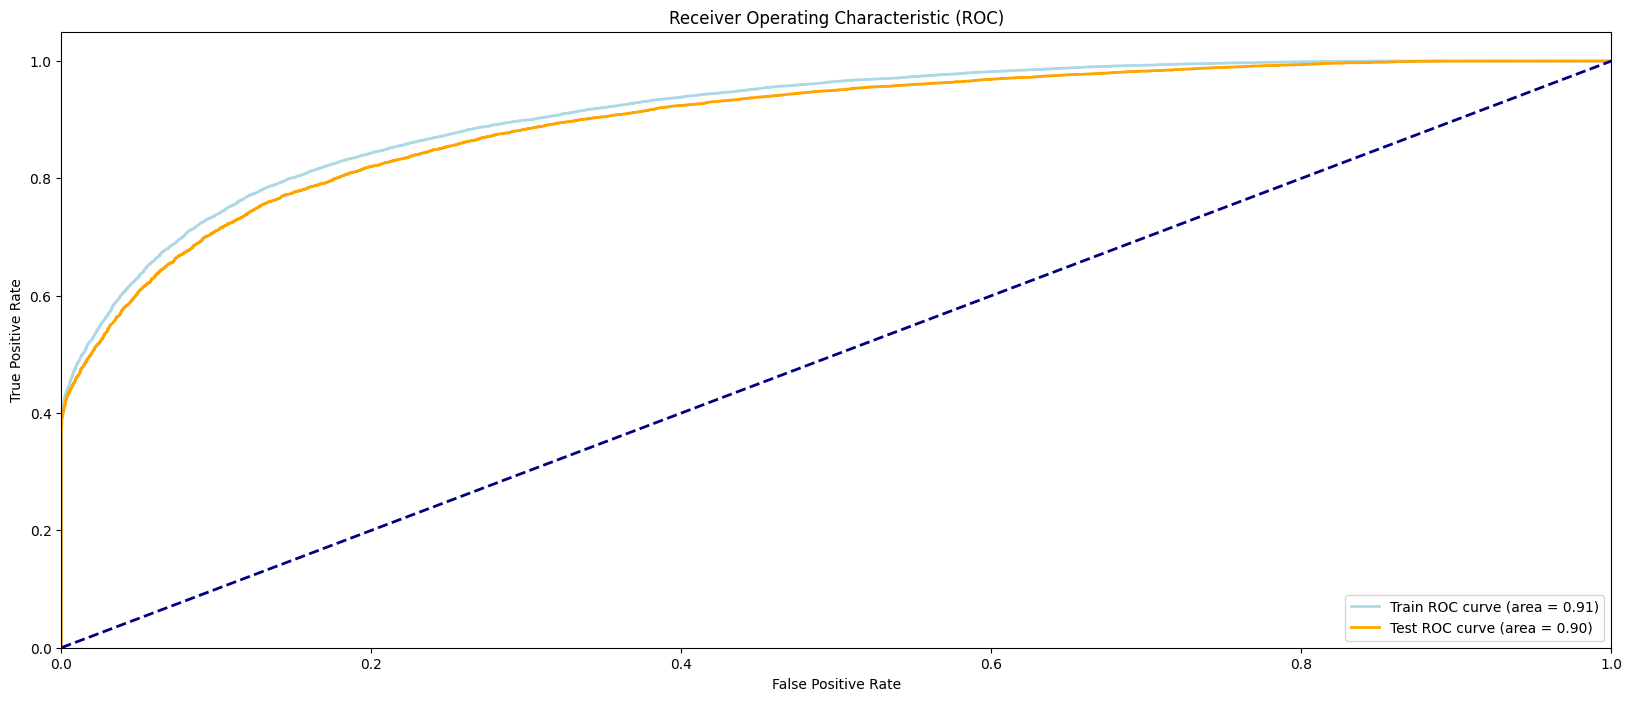

In [ ]:
# Plot ROC curve
plt.figure()
plt.plot(fpr_train, tpr_train, color='lightblue', lw=2, label='Train ROC curve (area = %0.2f)' % roc_auc_train)
plt.plot(fpr_test, tpr_test, color='orange', lw=2, label='Test ROC curve (area = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

### **Visualizing your tree**

`XGBoost` has two handy visualization functions for interpreting results.

The first is `plot_importance()`  which plots feature importance, meaning, how predictive each feature is for the target variable. It takes in the fitted XGBoost model.


#### **Plotting feature importance**

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

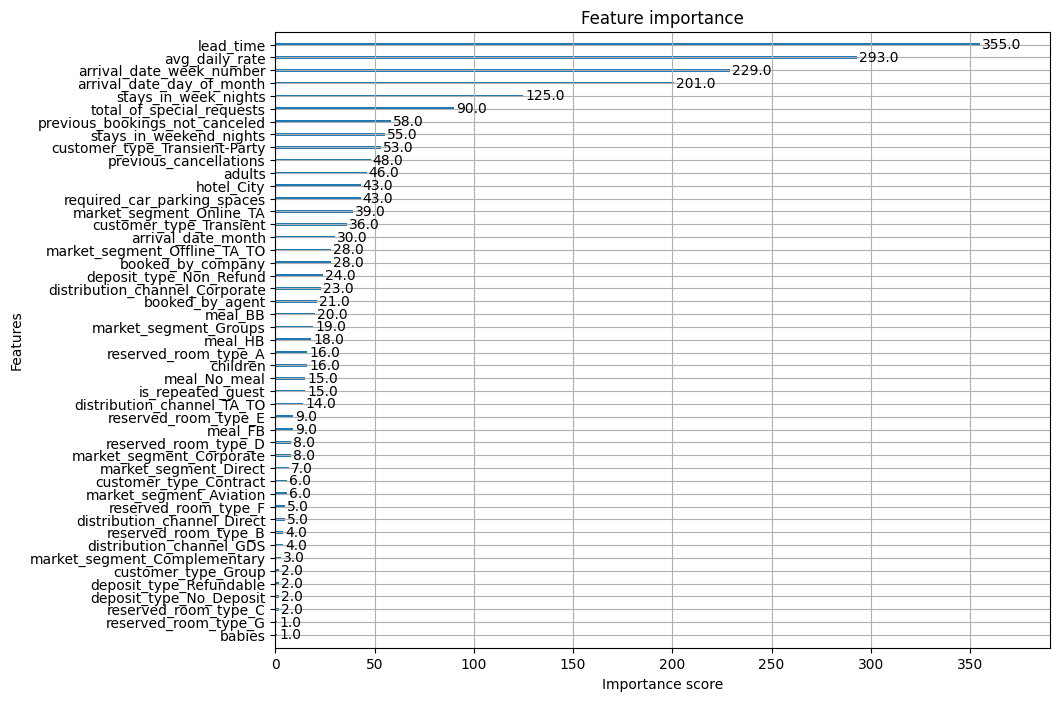

In [ ]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10.0, 8)

# Plot feature importance
xgb.plot_importance(xgb_rs.best_estimator_)

How is importance calculated? Here's an excerpt from the [documentation](https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.plotting):

> **importance_type (str, default "weight") –**
> How the importance is calculated: either “weight”, “gain”, or “cover”
> - ”weight” is the number of times a feature appears in a tree
> - ”gain” is the average gain of splits which use the feature
> - ”cover” is the average coverage of splits which use the feature where coverage is defined as the number of samples affected by the split

We'll focus on the first two. Gain is a way to quantify how much a feature contributes to improving accuracy. Let's try out `gain` to see how it differs from `weight`.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

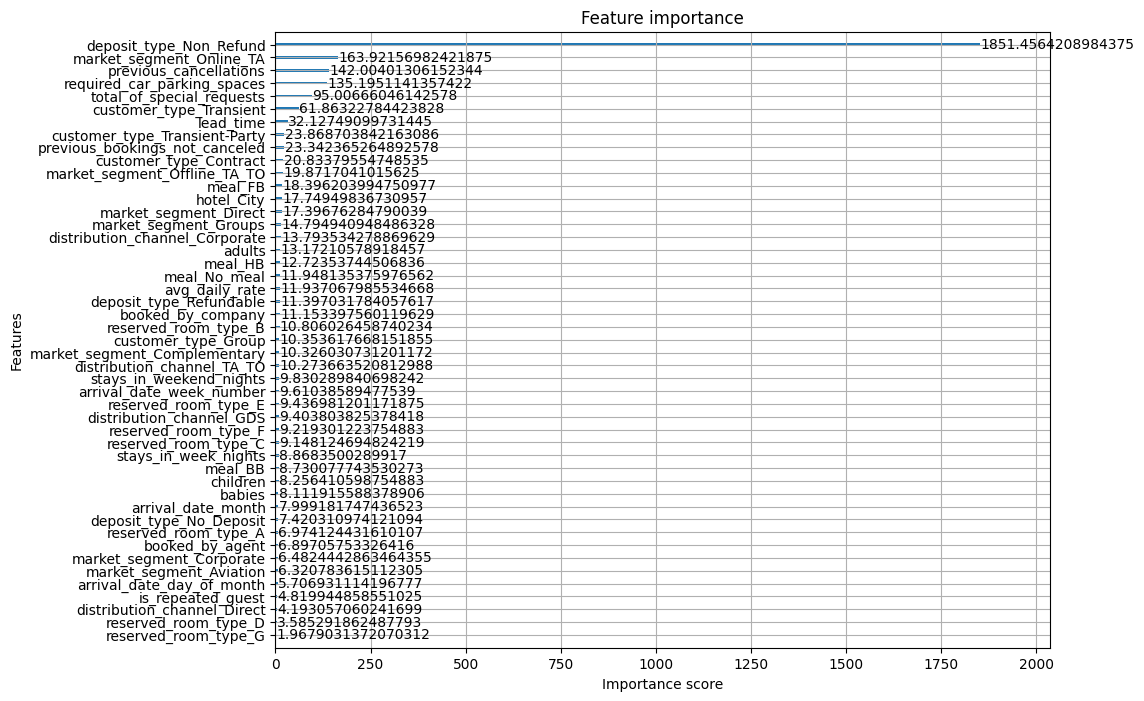

In [ ]:
# Plot gain instead of weight
xgb.plot_importance(xgb_rs.best_estimator_, importance_type="gain")

Here we see the ordering of features differs quite a bit between `gain` and `weight`! This implies that (1) feature importance can be subjective, and (2) the number of appearances a feature has on a tree is not necessarily correlated to how much gain it brings. For example, a binary variable has less of a chance to appear as many times as a continuous variable on a tree, since there are only two outputs. However, it can still be a powerful feature.

#### **Plotting a decision tree from your model**

The second handy visualization function is `plot_tree()` which visually generates a decision tree in your model. Remember, there are multiple trees in the model.

It takes in the fitted XGBoost model, and with the `num_trees` parameter, you can indicate which tree you want to see. For example, if I have `n_estimator=3`, I can set the `num_trees` parameter as `0`, `1`, or `2` to see the first, second, or third tree, respectively.

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Axes: >

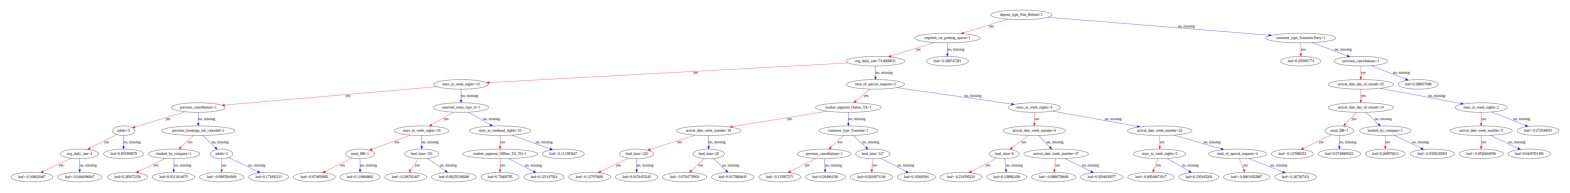

In [ ]:
matplotlib.rcParams['figure.figsize'] = (20.0, 8)

# Plot the first tree
xgb.plot_tree(xgb_rs.best_estimator_, num_trees=9)

The leaf output is the raw score. It's converted to a probability at the end of training.

There's a parameter called `rankdir`. We can set it to `LR` so the decision tree builds left to right, as opposed to top to bottom.

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Axes: >

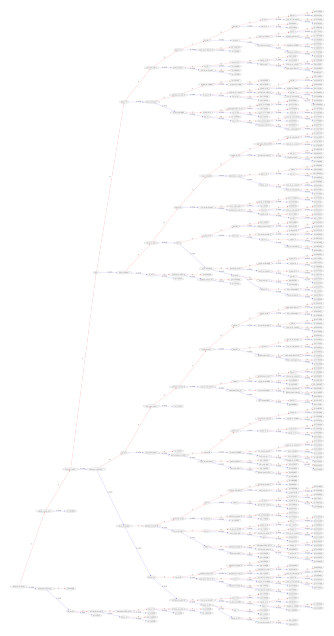

In [ ]:
# Plot the tree left to right
xgb.plot_tree(xgb_rs.best_estimator_, num_trees=9, rankdir='LR')

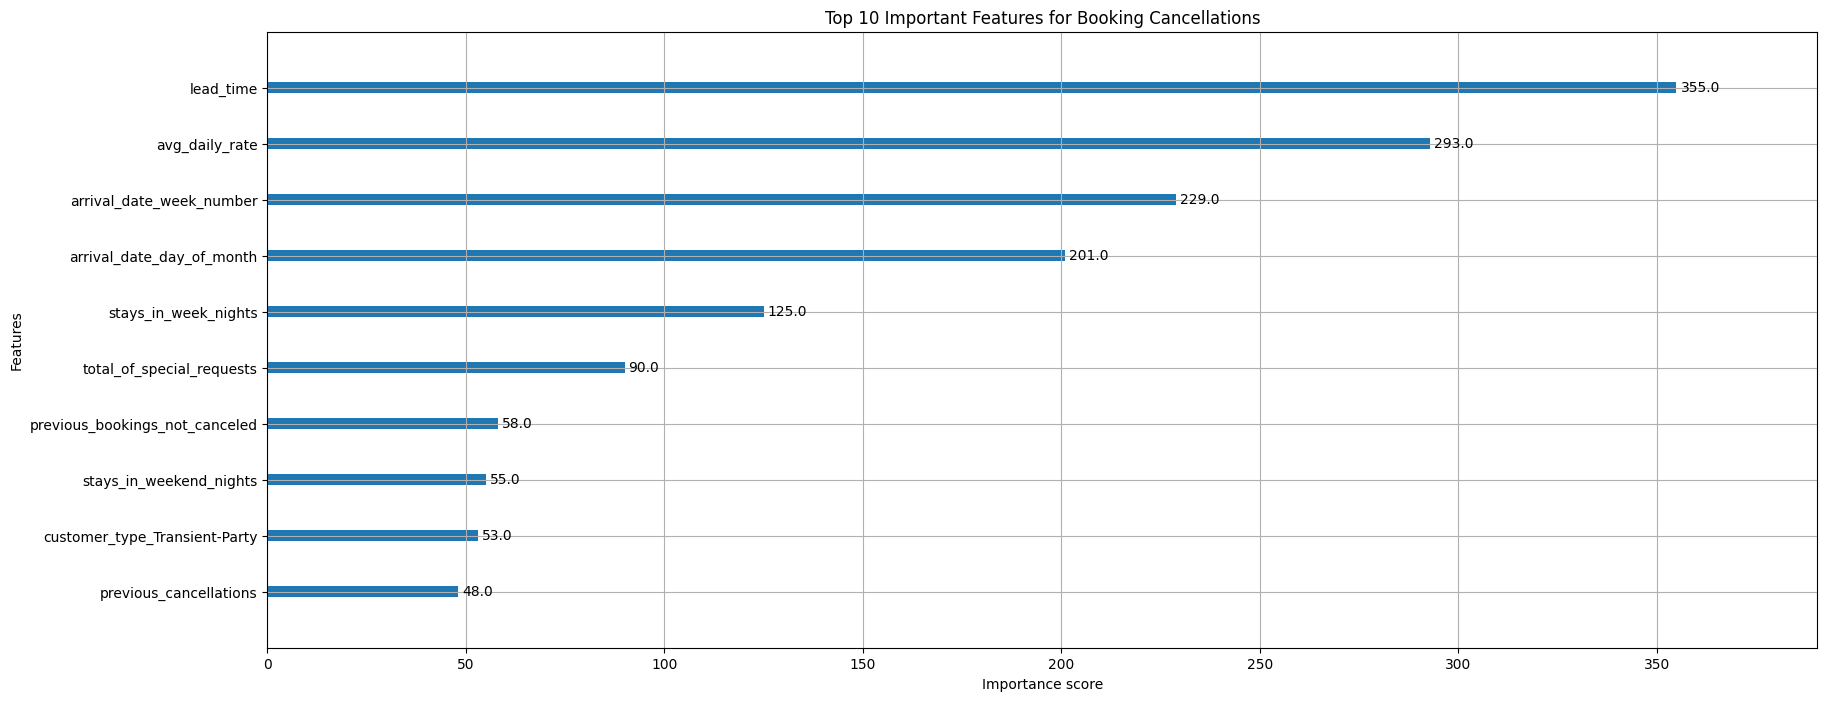

In [ ]:
import matplotlib.pyplot as plt

# Visualize the top 10 most important features to understand the model's decision-making process
# This helps identify the key drivers of booking cancellations (e.g., lead_time, ADR)
xgb.plot_importance(xgb_rs.best_estimator_, max_num_features=10)
plt.title("Top 10 Important Features for Booking Cancellations")
plt.show()

While plot_tree visualizes individual decision paths, I added plot_importance to gain a macro-level understanding of the model. This allows us to identify the key drivers of cancellations (like lead_time or ADR). From a business perspective, this 'Explainable AI' approach helps stakeholders understand why the model predicts a cancellation and which factors they should focus on to reduce booking losses.